# Lecture 6c — Backtesting Risk Models

**25882 AI-powered Investment and Risk Management** · UTS Business School

---

Notebook 06b produced volatility forecasts. This notebook asks the question that should
follow every risk number and usually does not: **was it right?**

That question turns out to be much harder than it sounds, for two reasons we will
demonstrate rather than assert:

1. The standard regulatory backtest has **very little power**. A model that breaches half
   again as often as it claims survives a 250-day test nine times out of ten.
2. Expected Shortfall — the measure Basel actually uses for capital — **cannot be
   backtested directly**, because it has no consistent scoring function on its own.

We finish with the approach that does work: **comparative** backtesting.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

import airm6 as a6

prices = a6.get_prices()
returns = a6.log_returns(prices)
r = a6.portfolio_returns(returns)

WINDOW, CONF = 250, 0.99
TAIL = a6.rp_alpha(CONF)          # 0.01

print(f"{len(r):,} days, {r.index.min().date()} to {r.index.max().date()}")

1,258 days, 2013-02-11 to 2018-02-07


---
## 1. Two defensible models, one portfolio

We build the two models from the opening slide of the lecture. Both are textbook, both
would pass an audit, and both use only information available on the day they are quoted.

- **Model A — historical simulation.** The empirical 1st percentile of the last 250 daily
  returns.
- **Model B — EWMA-normal.** An exponentially weighted variance with $\lambda = 0.94$,
  scaled by the Gaussian 99% quantile.

In [2]:
var_hs = (-r.rolling(WINDOW).quantile(TAIL).shift(1)).rename("Model A: HS(250)")
var_ewma = (np.sqrt(a6.ewma_var(r, lam=0.94, warmup=WINDOW))
            * stats.norm.ppf(CONF)).rename("Model B: EWMA-normal")

models = {"Model A: HS(250)": var_hs, "Model B: EWMA-normal": var_ewma}
test = var_hs.dropna().index.intersection(var_ewma.dropna().index)

for day in ["2017-12-29", "2018-02-06"]:
    d = pd.Timestamp(day)
    print(f"{d.date()}   A = {var_hs[d]*100:.2f}%   B = {var_ewma[d]*100:.2f}%")
print("\nThe ranking reverses between those two dates.")

2017-12-29   A = 1.42%   B = 0.93%
2018-02-06   A = 1.58%   B = 2.71%

The ranking reverses between those two dates.


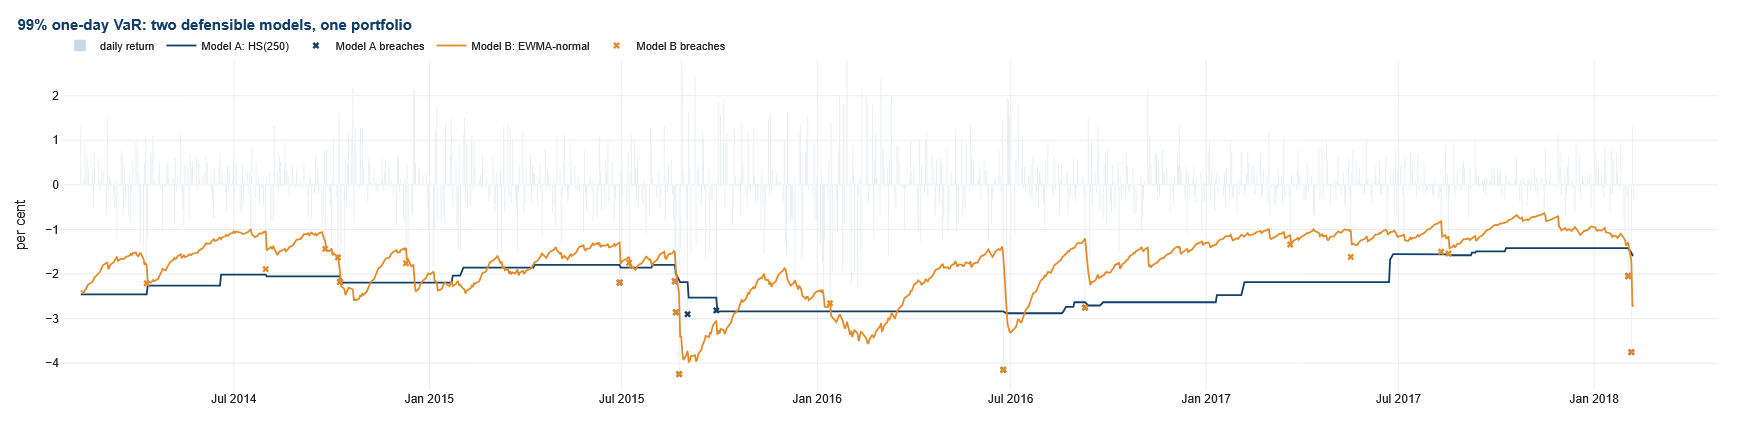

In [3]:
fig = go.Figure()
fig.add_trace(go.Bar(x=test, y=r.loc[test] * 100, name="daily return",
                     marker_color="#C9D6E4"))
for (name, v), colour in zip(models.items(), [a6.NAVY, a6.ORANGE]):
    fig.add_trace(go.Scatter(x=test, y=-v.loc[test] * 100, name=name,
                             line=dict(color=colour, width=1.8)))
    br = a6.breaches(r, v).loc[test]
    hit = r.loc[test][br.fillna(False)]
    fig.add_trace(go.Scatter(x=hit.index, y=hit * 100, mode="markers",
                             name=f"{name.split(':')[0]} breaches",
                             marker=dict(color=colour, size=6, symbol="x")))

a6.style(fig, title="99% one-day VaR: two defensible models, one portfolio",
         ytitle="per cent", height=440)
fig.update_yaxes(range=[-4.6, 2.8])
fig.show()

---
## 2. Counting breaches — the Kupiec test

A correct 99% model should be breached on about 1% of days. The
[Kupiec (1995)](https://doi.org/10.3905/jod.1995.407942) test asks whether the observed
breach *rate* is consistent with the claimed one.

<details>
<summary><b>The statistic (click to expand)</b></summary>

With $T$ observations, $x$ breaches, observed rate $\hat\pi = x/T$ and nominal breach
probability $p$:

$$\mathrm{LR}_{uc} = -2\log\frac{p^{x}(1-p)^{T-x}}{\hat\pi^{x}(1-\hat\pi)^{T-x}}
\;\overset{d}{\to}\; \chi^2_1$$

</details>

In [4]:
rows = {}
for name, v in models.items():
    ind = a6.breaches(r, v).dropna()
    rows[name] = a6.conditional_coverage(ind, p=TAIL)

summary = pd.DataFrame(rows).T
display(summary[["n", "breaches", "rate %", "expected", "LR_uc", "p_uc"]]
        .style.format({"n": "{:.0f}", "breaches": "{:.0f}", "rate %": "{:.2f}",
                       "expected": "{:.1f}", "LR_uc": "{:.2f}", "p_uc": "{:.4f}"})
        .set_caption("Kupiec unconditional coverage"))

,n,breaches,rate %,expected,LR_uc,p_uc
Model A: HS(250),1008,11,1.09,10.1,0.08,0.7741
Model B: EWMA-normal,1008,20,1.98,10.1,7.67,0.0056


Model A passes comfortably. Model B breaches roughly twice as often as it should and is
rejected at any conventional level.

So far the test has done its job. Now watch it fail in the other direction.

---
## 3. Clustering — the Christoffersen test

Getting the *rate* right is not enough. A correct model should also produce breaches that
are **unpredictable**: a breach today should not raise the odds of one tomorrow. If breaches
arrive in clusters, the model's *level* is calibrated but its *dynamics* are not — and it
will be wrong precisely when losses are largest.

[Christoffersen (1998)](https://doi.org/10.2307/2527341) tests this against a first-order
Markov alternative.

In [5]:
display(summary[["breaches", "p_uc", "LR_ind", "p_ind", "LR_cc", "p_cc"]]
        .style.format({"breaches": "{:.0f}", "p_uc": "{:.4f}", "LR_ind": "{:.2f}",
                       "p_ind": "{:.4f}", "LR_cc": "{:.2f}", "p_cc": "{:.4f}"})
        .set_caption("Coverage, independence, and the two combined"))

for name in models:
    row = summary.loc[name]
    verdict_uc = "PASSES" if row["p_uc"] > 0.05 else "FAILS"
    verdict_ind = "PASSES" if row["p_ind"] > 0.05 else "FAILS"
    print(f"{name:<24s} coverage {verdict_uc:6s} (p={row['p_uc']:.3f})   "
          f"independence {verdict_ind:6s} (p={row['p_ind']:.3f})")

,breaches,p_uc,LR_ind,p_ind,LR_cc,p_cc
Model A: HS(250),11,0.7741,15.23,0.0001,15.32,0.0005
Model B: EWMA-normal,20,0.0056,7.66,0.0057,15.32,0.0005


Model A: HS(250)         coverage PASSES (p=0.774)   independence FAILS  (p=0.000)
Model B: EWMA-normal     coverage FAILS  (p=0.006)   independence FAILS  (p=0.006)


**This is the result worth pausing on.** Model A — the one that passed the coverage test
comfortably — fails the independence test decisively. Its breaches cluster.

That is exactly what you would expect from a 250-day rolling window: the estimate reacts
slowly, so when volatility rises the model stays too low for weeks and is breached
repeatedly, then over-corrects. A risk manager reading only the breach count would sign it
off.

Let us look at *when* the breaches happened.

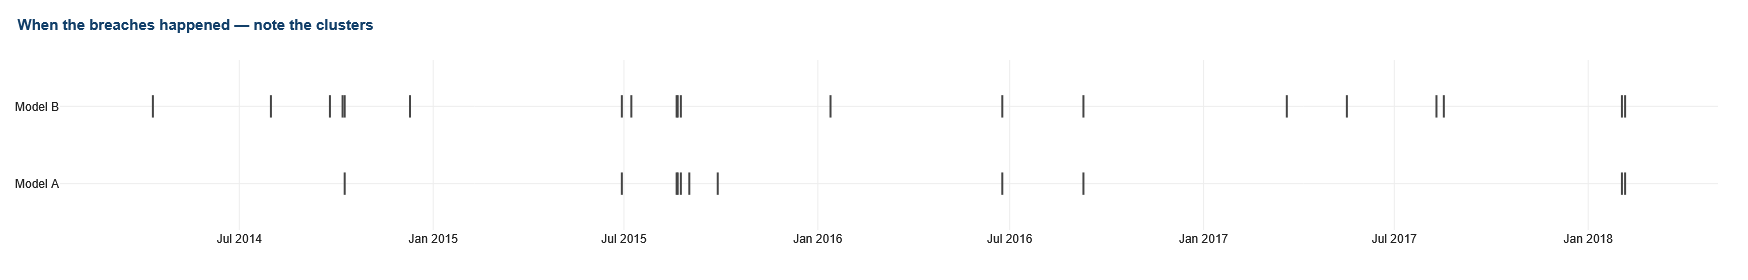

Model A: HS(250)         median gap between breaches:    28 days   shortest: 1 day(s)   breaches within 5 days of another: 3
Model B: EWMA-normal     median gap between breaches:    40 days   shortest: 1 day(s)   breaches within 5 days of another: 5


In [6]:
fig = go.Figure()
for i, (name, v) in enumerate(models.items()):
    br = a6.breaches(r, v).loc[test].fillna(False)
    hits = br[br].index
    fig.add_trace(go.Scatter(
        x=hits, y=np.full(len(hits), i), mode="markers", name=name,
        marker=dict(symbol="line-ns", size=16, line_width=2,
                    color=[a6.NAVY, a6.ORANGE][i])))

a6.style(fig, title="When the breaches happened — note the clusters", height=280)
fig.update_yaxes(tickvals=[0, 1], ticktext=["Model A", "Model B"], range=[-0.6, 1.6])
fig.update_layout(showlegend=False)
fig.show()

for name, v in models.items():
    br = a6.breaches(r, v).loc[test].fillna(False)
    gaps = np.diff(np.flatnonzero(br.to_numpy()))
    print(f"{name:<24s} median gap between breaches: {np.median(gaps):5.0f} days   "
          f"shortest: {gaps.min()} day(s)   breaches within 5 days of another: "
          f"{int(np.sum(gaps <= 5))}")

---
## 4. Basel's traffic light

Supervisors do not run these tests on the full sample. They run a **250-day window** and
sort the result into three zones: green (0–4 breaches), yellow (5–9) and red (10 or more),
with the capital multiplier rising through the yellow zone.

Let us apply that rule to every rolling window in our sample.

In [7]:
zones = pd.DataFrame({name: a6.rolling_zone_summary(a6.breaches(r, v).dropna(), WINDOW)
                      for name, v in models.items()}).T
display(zones.style.format({"windows": "{:.0f}", "min": "{:.0f}", "max": "{:.0f}",
                            "green %": "{:.0f}%", "yellow %": "{:.0f}%", "red %": "{:.0f}%"})
        .set_caption("Basel traffic-light zone across rolling 250-day windows"))

,windows,min,max,green %,yellow %,red %
Model A: HS(250),759,0,7,67%,33%,0%
Model B: EWMA-normal,759,2,9,47%,53%,0%


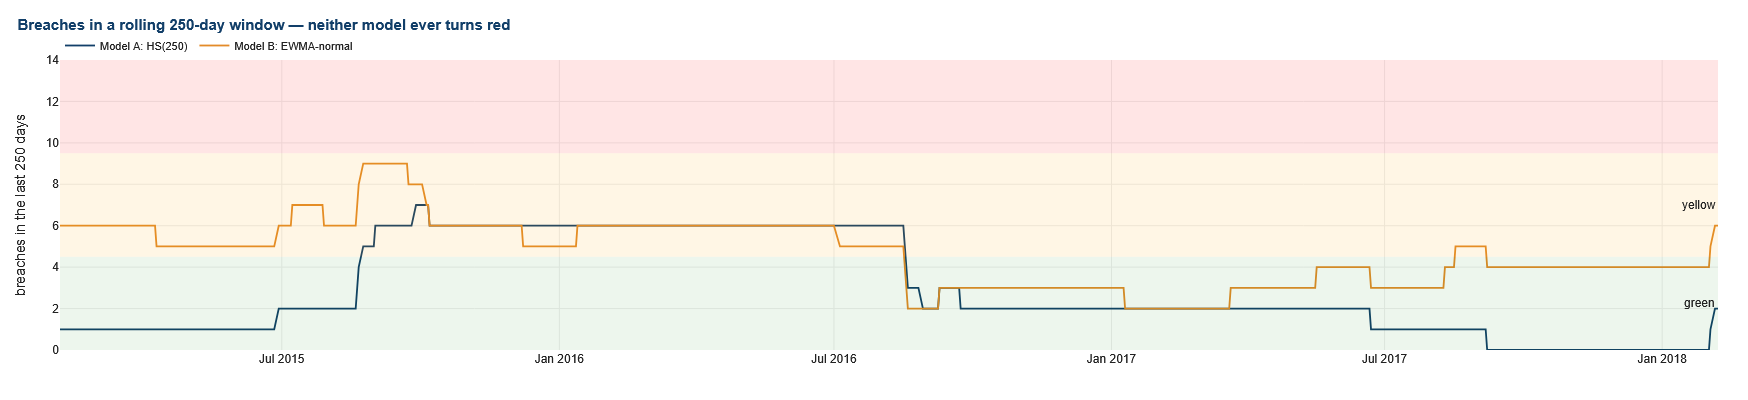

In [8]:
fig = go.Figure()
for (name, v), colour in zip(models.items(), [a6.NAVY, a6.ORANGE]):
    counts = a6.breaches(r, v).dropna().rolling(WINDOW).sum().dropna()
    fig.add_trace(go.Scatter(x=counts.index, y=counts, name=name,
                             line=dict(color=colour, width=1.8)))
fig.add_hrect(y0=0, y1=4.5, fillcolor="green", opacity=0.07, line_width=0,
              annotation_text="green", annotation_position="right")
fig.add_hrect(y0=4.5, y1=9.5, fillcolor="orange", opacity=0.10, line_width=0,
              annotation_text="yellow", annotation_position="right")
fig.add_hrect(y0=9.5, y1=20, fillcolor="red", opacity=0.10, line_width=0,
              annotation_text="red", annotation_position="right")

a6.style(fig, title="Breaches in a rolling 250-day window — neither model ever turns red",
         ytitle="breaches in the last 250 days", height=400)
fig.update_yaxes(range=[0, 14])
fig.show()

**Neither model ever reaches the red zone**, including Model B — which we already know
breaches at twice its stated rate. The regulatory test, applied as regulators apply it,
does not flag a model we rejected outright three sections ago.

That is not a flaw in the arithmetic. It is a power problem, and it is worth quantifying.

---
## 5. How little a backtest can see

At 99% over 250 days you expect 2.5 breaches. Distinguishing a correct model from a badly
wrong one on that sample is close to hopeless. Let us simulate the test's **power**: the
probability of correctly rejecting a model whose true breach rate is worse than claimed.

In [9]:
lengths = [250, 375, 500, 750, 1000, 1500, 2000, 2500]
scenarios = {"1.3% (30% too thin)": 0.013,
             "1.5% (50% too thin)": 0.015,
             "2.0% (twice too thin)": 0.020}

power = pd.DataFrame(
    {label: [100 * a6.kupiec_power(rate, n, p=TAIL) for n in lengths]
     for label, rate in scenarios.items()},
    index=lengths)
power.index.name = "backtest length (days)"
display(power.style.format("{:.0f}%")
        .set_caption("Probability of rejecting a mis-specified 99% VaR model"))

,1.3% (30% too thin),1.5% (50% too thin),2.0% (twice too thin)
backtest length (days),,,
250,8%,11%,24%
375,7%,12%,34%
500,13%,22%,54%
750,12%,24%,64%
1000,16%,34%,78%
1500,18%,40%,89%
2000,24%,52%,96%
2500,29%,62%,98%


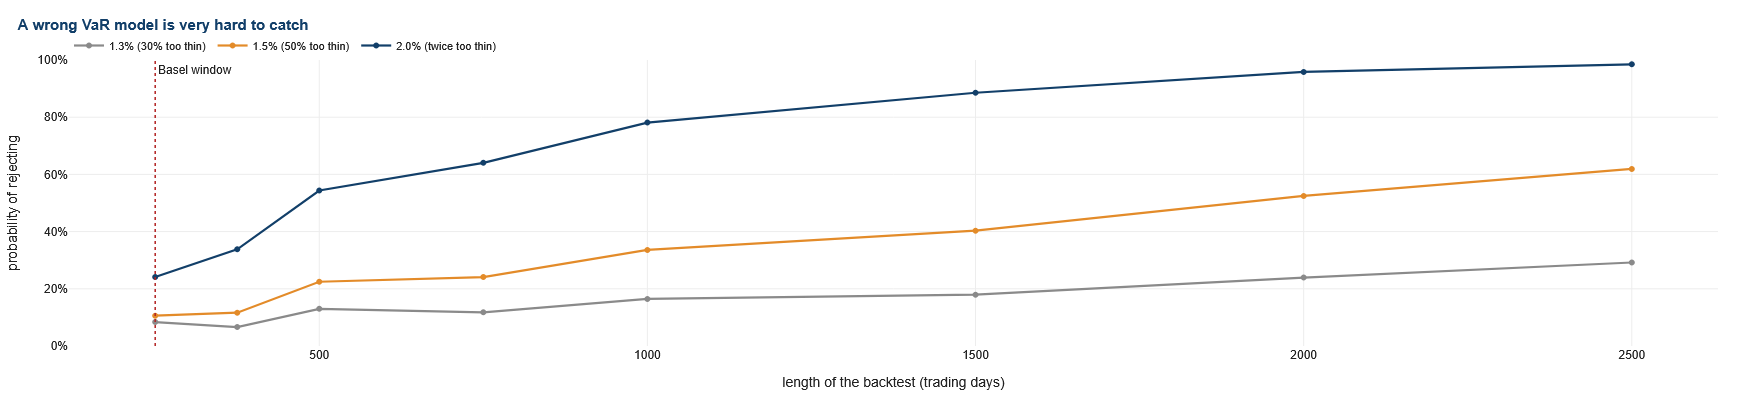

A model 50% too thin is caught 11% of the time in 250 days,
and still only 62% of the time after ten years of daily data.


In [10]:
fig = go.Figure()
for (label, _), colour in zip(scenarios.items(), [a6.GREY, a6.ORANGE, a6.NAVY]):
    fig.add_trace(go.Scatter(x=lengths, y=power[label], name=label, mode="lines+markers",
                             line=dict(color=colour, width=2.2)))
fig.add_vline(x=250, line=dict(color=a6.RED, width=1.5, dash="dot"),
              annotation_text="Basel window", annotation_position="top right")

a6.style(fig, title="A wrong VaR model is very hard to catch",
         xtitle="length of the backtest (trading days)",
         ytitle="probability of rejecting", height=400)
fig.update_yaxes(range=[0, 100], ticksuffix="%")
fig.show()

print(f"A model 50% too thin is caught {power.loc[250, '1.5% (50% too thin)']:.0f}% "
      f"of the time in 250 days,")
print(f"and still only {power.loc[2500, '1.5% (50% too thin)']:.0f}% of the time "
      "after ten years of daily data.")

**Treat the two outcomes asymmetrically.** Failing a backtest is strong evidence that
something is wrong. Passing one is weak evidence that anything is right.

---
## 6. Why ES cannot be backtested this way

Notebook 06a showed that VaR is not subadditive and that FRTB therefore moved bank capital
to 97.5% Expected Shortfall. Here is the catch.

A functional is **elicitable** if some scoring function $S(\hat y, y)$ is minimised, in
expectation, by the true value. That is what lets you fit a model to it, rank two models on
it, and test it.

- **VaR is elicitable.** Its scoring function is the pinball (tick) loss.
- **ES is not elicitable on its own** ([Gneiting, 2011](https://doi.org/10.1198/jasa.2011.r10138)).
- **But the pair $(\mathrm{VaR}, \mathrm{ES})$ is *jointly* elicitable**
  ([Fissler and Ziegel, 2016](https://doi.org/10.1214/16-AOS1439)).

Rather than take this on trust, let us verify it numerically on data where we know the
right answer.

In [11]:
rng = np.random.default_rng(0)
sample = rng.standard_normal(400_000) * 0.01
tail = 0.025

v_true = float(np.quantile(sample, tail))
e_true = float(sample[sample <= v_true].mean())
print(f"Known truth:   VaR = {v_true:.5f}    ES = {e_true:.5f}")

# 1. Pinball loss recovers the quantile
grid_v = np.linspace(v_true * 0.7, v_true * 1.3, 121)
pin = [a6.pinball_loss(sample, v, tail) for v in grid_v]
print(f"Pinball loss minimised at VaR = {grid_v[int(np.argmin(pin))]:.5f}")

# 2. FZ0 loss recovers BOTH at once
grid_e = np.linspace(e_true * 0.7, e_true * 1.3, 121)
surface = np.array([[a6.fz0_loss(sample, v, e, tail) for e in grid_e] for v in grid_v])
iv, ie = np.unravel_index(surface.argmin(), surface.shape)
print(f"FZ0 loss    minimised at VaR = {grid_v[iv]:.5f}    ES = {grid_e[ie]:.5f}")

Known truth:   VaR = -0.01962    ES = -0.02345
Pinball loss minimised at VaR = -0.01962
FZ0 loss    minimised at VaR = -0.01962    ES = -0.02345


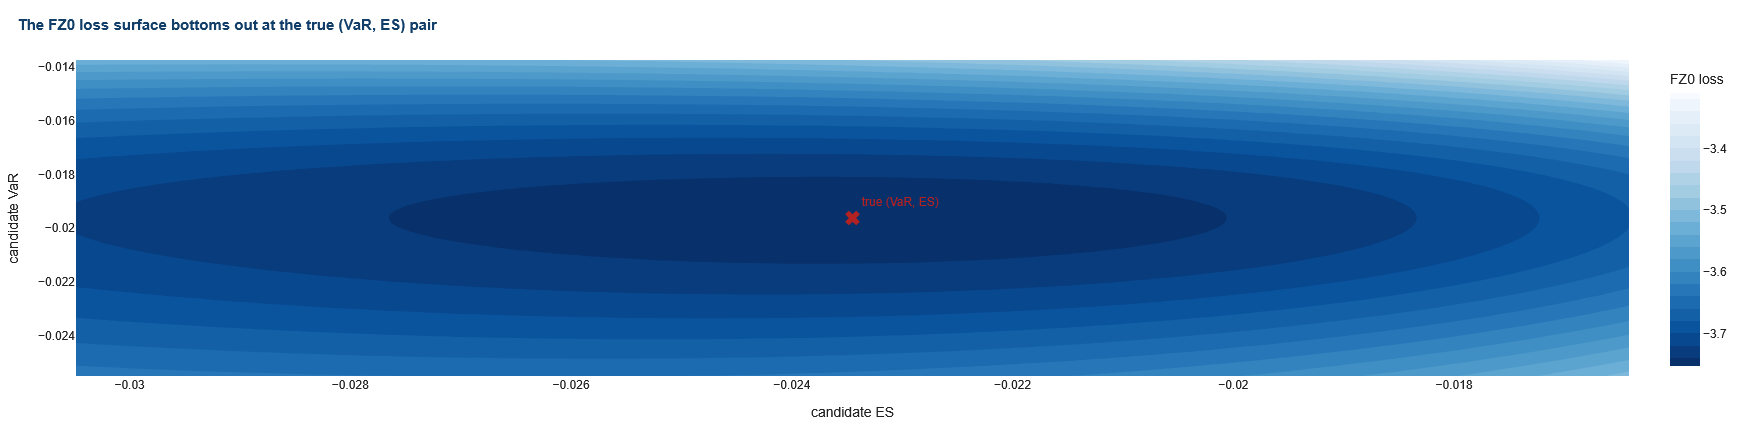

In [12]:
fig = go.Figure(go.Contour(
    x=grid_e, y=grid_v, z=surface, colorscale="Blues_r", ncontours=30,
    contours=dict(showlines=False), colorbar=dict(title="FZ0 loss")))
fig.add_trace(go.Scatter(x=[e_true], y=[v_true], mode="markers+text",
                         marker=dict(color=a6.RED, size=13, symbol="x"),
                         text=["true (VaR, ES)"], textposition="top right",
                         textfont=dict(color=a6.RED), showlegend=False))

a6.style(fig, title="The FZ0 loss surface bottoms out at the true (VaR, ES) pair",
         xtitle="candidate ES", ytitle="candidate VaR", height=430, legend_top=False)
fig.show()

The minimum sits exactly on the truth. **That is joint elicitability, made concrete** — and
it is why a neural network can be trained to output a VaR and an ES simultaneously by
minimising this loss directly ([Patton, Ziegel and Chen,
2019](https://doi.org/10.1016/j.jeconom.2018.10.008)).

Note what we could *not* do: draw the equivalent one-dimensional picture for ES alone. No
such scoring function exists. The pair is the smallest object that can be scored.

---
## 7. Comparative backtesting — the approach that works

Sections 2–5 asked *"is this model correct?"* and discovered the test has almost no power.
[Nolde and Ziegel (2017)](https://doi.org/10.1214/17-AOAS1041) argue for a different
question: **"is model A better than model B?"**

Comparative tests use the same data far more efficiently, because differencing two loss
series removes the common noise that swamps the absolute test. We score both models with
FZ0 and compare with a Diebold–Mariano test.

In [13]:
# ES forecasts consistent with each VaR model
es_models = {}
for name, v in models.items():
    if "HS" in name:
        # historical: mean of returns below the rolling quantile
        es = r.rolling(WINDOW).apply(
            lambda w: w[w <= np.quantile(w, TAIL)].mean(), raw=True).shift(1)
    else:
        # Gaussian closed form: ES = -sigma * phi(z_a)/a
        sigma = np.sqrt(a6.ewma_var(r, lam=0.94, warmup=WINDOW))
        es = -sigma * stats.norm.pdf(stats.norm.ppf(TAIL)) / TAIL
    es_models[name] = es

idx = test
per_obs = {}
for name, v in models.items():
    vv = (-v.loc[idx]).to_numpy()            # VaR as a negative return level
    ee = es_models[name].loc[idx].to_numpy()
    yy = r.loc[idx].to_numpy()
    ok = np.isfinite(vv) & np.isfinite(ee) & (ee < 0)
    hit = (yy[ok] <= vv[ok]).astype(float)
    per_obs[name] = ((-1.0 / (TAIL * ee[ok])) * hit * (vv[ok] - yy[ok])
                     + vv[ok] / ee[ok] + np.log(-ee[ok]) - 1.0)

names = list(models)
n = min(len(per_obs[k]) for k in names)
loss_a, loss_b = per_obs[names[0]][-n:], per_obs[names[1]][-n:]

print(f"mean FZ0 loss   {names[0]:<24s} {loss_a.mean():.4f}")
print(f"mean FZ0 loss   {names[1]:<24s} {loss_b.mean():.4f}")
stat, pval = a6.diebold_mariano(loss_a, loss_b, lag=5)
better = names[0] if stat < 0 else names[1]
print(f"\nDiebold-Mariano statistic {stat:+.3f}   p-value {pval:.4f}")
print(f"-> {better} has the lower expected loss"
      f"{' (significant at 5%)' if pval < 0.05 else ' (not significant at 5%)'}")

mean FZ0 loss   Model A: HS(250)         -3.3999
mean FZ0 loss   Model B: EWMA-normal     -3.1957

Diebold-Mariano statistic -1.041   p-value 0.2979
-> Model A: HS(250) has the lower expected loss (not significant at 5%)


**Read that result carefully, because it is more interesting than a clean win.**

The comparative test points to Model A, but it does *not* reject equal accuracy at the 5%
level. Meanwhile Section 2's coverage test rejected Model B outright at $p = 0.006$. Two
tests, two different answers about the same pair of models. How?

They are asking different questions. The coverage test looks only at **how often** the VaR
threshold was breached, and Model B breaches twice as often as it claims. FZ0 scores the
**whole tail forecast** — the VaR *and* the ES together — and Model B's exponentially
weighted variance produces a far more responsive ES than Model A's 250-day window. Model B
is badly calibrated at the threshold and comparatively well behaved beyond it. Averaged
into a single joint loss, those two effects substantially cancel.

So the honest summary is:

- Comparative backtesting asks a question the data **can** answer, and its power scales
  better than an absolute test, because differencing two loss series removes the common
  noise. That is the argument in [Nolde and Ziegel
  (2017)](https://doi.org/10.1214/17-AOAS1041), and it holds.
- It is **not** a free upgrade. Roughly 1,000 observations of a heavy-tailed loss is still
  not much, and here it is not enough to separate two genuinely different models at 5%.
- Most importantly, **a joint score can hide a specific failure**. If your mandate is a VaR
  limit, Model B is unacceptable regardless of what FZ0 says about its tail behaviour.

Report both. The comparative test tells you which model to prefer; the coverage test tells
you which one will get you a phone call from your supervisor. This is the same argument
Lecture 5 made about strategy evaluation — a relative, out-of-sample horse race is more
informative than an absolute verdict — with the caveat that the aggregate can conceal the
detail you are actually accountable for.

---
## Exercises

### Core

**C1.** Add a third model: a Student-$t$ EWMA that uses the same variance but the
$t$ quantile with $\nu = 4$ instead of the Gaussian one. Does it fix Model B's coverage
problem? Does it fix the clustering?

**C2.** Model A fails the independence test. Shorten its window from 250 days to 60 and
rerun both tests. You should find coverage worsens as clustering improves — explain the
trade-off in two sentences.

**C3.** Compute the Basel capital multiplier implied by each model's *worst* 250-day
window, using the standard scale (3.0 in the green zone, rising to 4.0 at 10 breaches).
How much extra capital does Model B's poor calibration cost?

### Stretch

**S1.** The Kupiec power curves assume breaches are independent. Simulate a mis-specified
model whose breaches *cluster* (say, a two-state Markov model) and recompute the power of
the Kupiec test. Does clustering make the coverage test more or less able to detect the
problem?

**S2.** Implement the [Acerbi and Székely (2014)](https://www.risk.net) $Z_2$ statistic for
ES and apply it to both models. Compare its verdict with the Diebold–Mariano comparison in
Section 7. Which gives you more actionable information, and why?

**S3.** Take the best volatility model from Notebook 06b, convert its forecasts into a 99%
VaR and ES series under a Student-$t$ assumption, and score it against both models here
with FZ0. Does a better *variance* forecast translate into a better *tail* forecast? This is
not automatic, and the answer tells you whether Section 3 of the lecture actually helps with
Section 4.